In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
import Soccer_OCEL.utils as utils

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [ ]:
#load all
path='data/28196177'
#games=get_games(path)
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        #GD_loaded.join_events(log='MOVEMENT')
        GD_loaded=assign_roles_multi(GD_loaded, team=True)
        GD_loaded.format_log()
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values(["attribute:game","attribute:session", "attribute:frame"]).reset_index(drop=True)

In [57]:
#load all
path='data/28196177'
#games=get_games(path)
#games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_simplified_teamed_epos.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [4]:
from pm4py.statistics.start_activities.log import get as start_get
from pm4py.statistics.end_activities.log import get as end_get
event_log = pm4py.convert_to_event_log(allgame_df)
start_activities = start_get.get_start_activities(event_log)
#end_activities = end_get.get_end_activities(event_log)
start_activities#, end_activities


{'Pass': 13,
 'Holding Central Defensive First': 7,
 'Pass_Intercepted': 379,
 'BallClaiming': 100,
 'TacklingGame': 101,
 'Wing Transition': 7,
 'PenaltyNotAwarded': 8,
 'Holding Wing Attack Third': 2,
 'Cross_Intercepted': 55,
 'Lateral Repositioning': 7,
 'Central Retreat': 5,
 'OtherBallAction': 15,
 'Wing Retreat': 1,
 'Central Transition': 5,
 'Penalty_ShotAtGoal': 1,
 'Holding Wing Defensive First': 4,
 'Holding Central Attack Third': 4,
 'SpectacularPlay': 1,
 'Wing Advance': 1,
 'Holding Wing Midfield': 3,
 'FreeKick_ShotAtGoal': 2,
 'Diagonal Repositioning': 1,
 'ThrowIn': 1,
 'Holding Central Midfield': 3}

In [6]:
allgame_df=utils.add_pass_cross_sequences(allgame_df)

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:226: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_action = df['concept:name'].str.contains(r'(pass|cross)', case=False, na=False)
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:227: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_excluded = df['concept:name'].str.contains(r'(received|intercepted)', case=False, na=False)


In [55]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))
                       &allgame_df['attribute:team'].str.contains('Home')
                       &(allgame_df['attribute:outcome']==0)
                         ]
shot_df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
end=shot_df[(shot_df['concept:name'].str.contains('Blocked'))
                          ]
shot_df = shot_df[shot_df['case:concept:name'].isin(end['case:concept:name'])]
shot_df=utils.filter_players_involved_with_ball(shot_df)

event_log = pm4py.convert_to_event_log(shot_df)

In [80]:
np.unique(end['Player'], return_counts=True)

(array(['DFL-OBJ-00003X', 'DFL-OBJ-00008K', 'DFL-OBJ-0000F8',
        'DFL-OBJ-0000NZ', 'DFL-OBJ-0026RH', 'DFL-OBJ-002FXT',
        'DFL-OBJ-002GM1', 'DFL-OBJ-J0130T', 'DFL-OBJ-J014L2',
        'DFL-OBJ-J01KJ5'], dtype=object),
 array([1, 2, 1, 1, 1, 1, 2, 1, 1, 1]))

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'Pass_Received_r5' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")
/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'Pass_Received_r2' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")
/Users/vitochan/Documents/phd/Projects/Soccer/.venv/

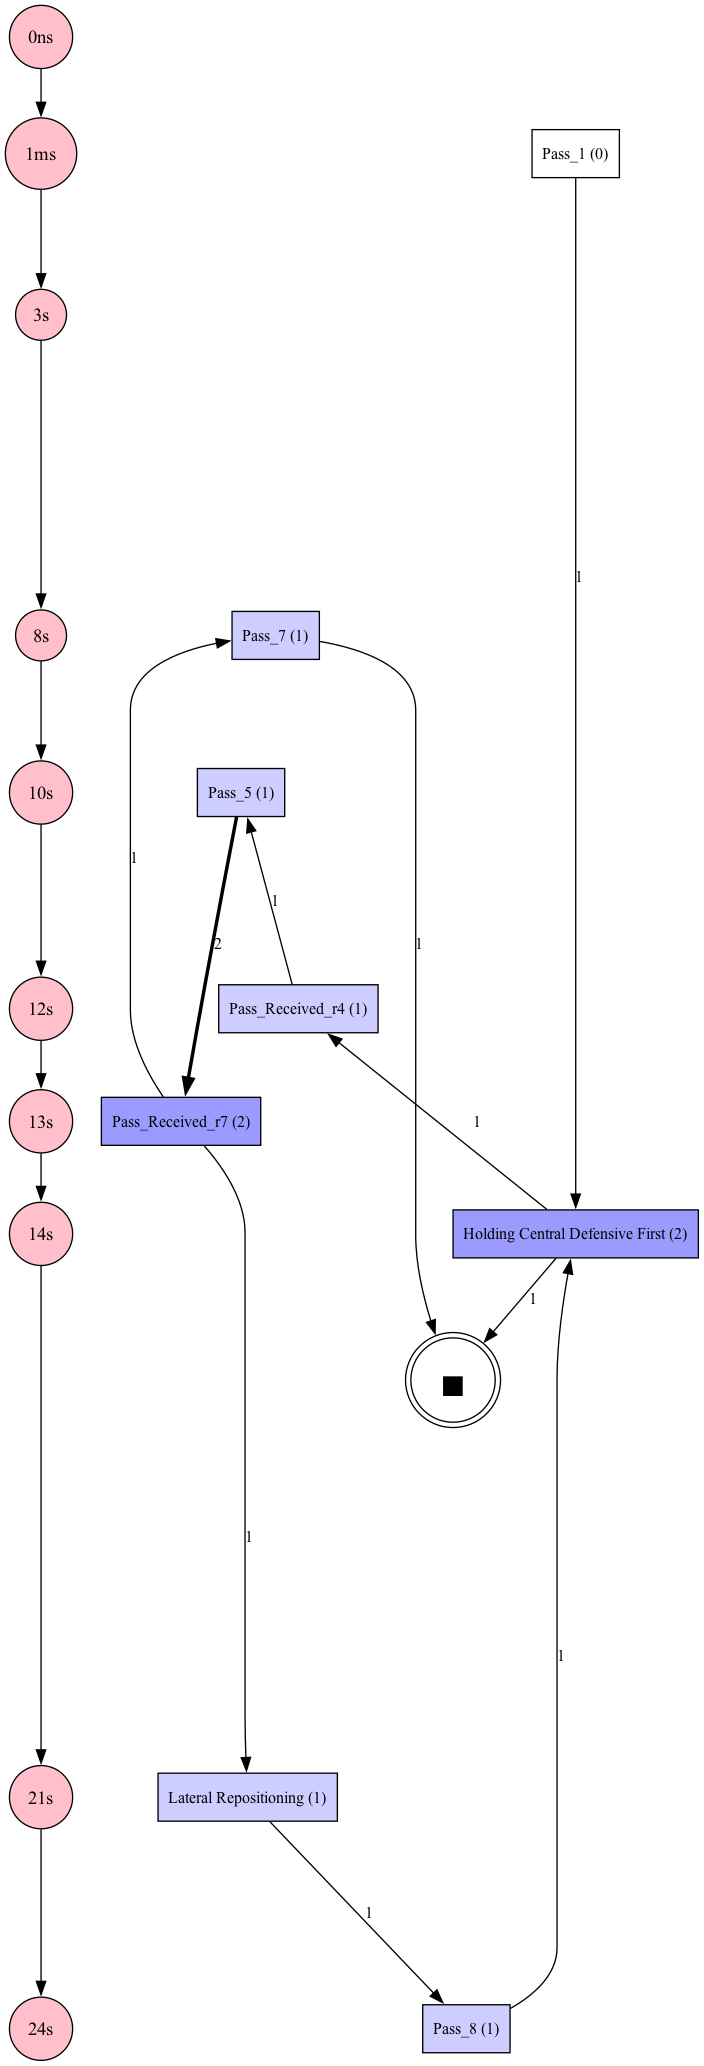

In [37]:
#log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
log = shot_df[~shot_df['Goalkeeper'].isna()]
#log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log, parameters={"aggregation": "mean"})
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

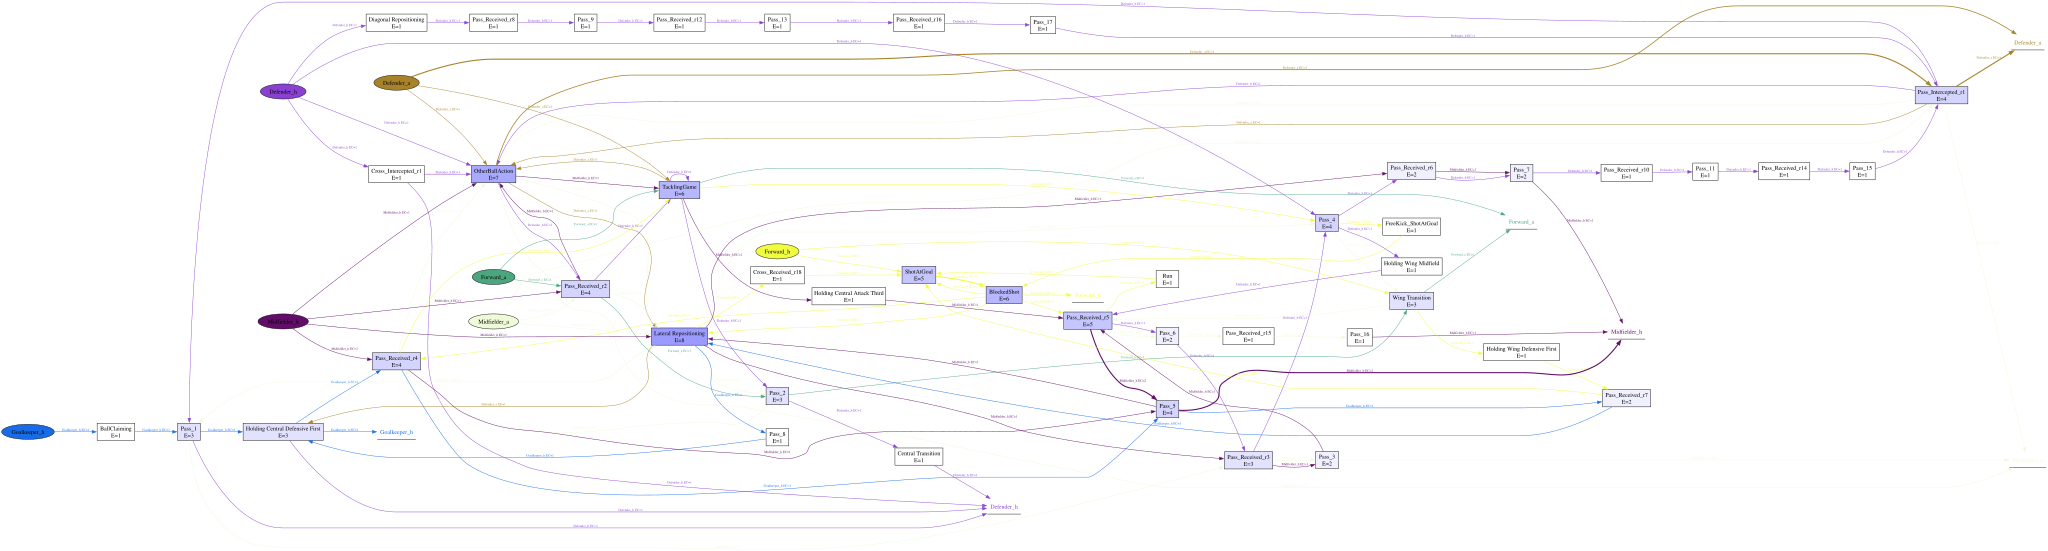

In [56]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     ,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
dfg=pm4py.ocel.discover_ocdfg(ocel,business_hours=True)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)